In [172]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy.stats import mode

In [173]:
#to display all the columns and all the rows 
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x) #this will reduce the decimal values after point

import warnings
warnings.filterwarnings("ignore")

In [174]:
Ins_data = pd.read_csv("Insurance Data.csv")

In [175]:
#creating a new df so that we can do all engineering and analysis their
main_data = Ins_data.copy()

In [176]:
main_data.head(10)

,Age,Gender,Marital Status,Family Members,Education,Occupation,Job Title,Income,Current Product,Current Product Type,Current_Coverage,New Product Type,New_Coverage,Rating,Converted,Status
0,18.00,M,Single,3.00,NE,SPT,DD,1.00,No,NO,0.00,INV,15000000.00,Cold,Converted,Converted
1,46.00,M,Married,5.00,PD,SE,FH,2.51,Yes,TLE,50000.00,ANS,2000000.00,Cold,NotConverted,AS
2,23.00,M,Married,2.00,BD,SPT,PG,9.00,No,NO,0.00,ANS,1000000.00,Hot,Converted,Converted
3,20.00,M,Single,6.00,NE,SPT,OM,2.42,No,NO,0.00,END,1000000.00,Warm,Converted,Converted
4,48.00,NaN,Married,4.00,BD,SPT,PG,9.64,Yes,ANS,15000000.00,INV,15000000.00,Warm,NotConverted,PS
5,45.00,M,Single,6.00,MD,SPT,PR,6.50,Yes,ANS,15000000.00,TLE,3000000.00,Warm,Converted,Converted
6,55.00,F,Married,4.00,BD,SE,FH,3.00,Yes,TLE,15000000.00,ANS,2000000.00,Cold,NotConverted,PN
7,58.00,M,Married,9.00,BD,SPT,PG,10.00,Yes,ANS,2000000.00,INV,2000000.00,Warm,Converted,Converted
8,20.00,M,Single,7.00,UHS,SPT,OM,2.00,Yes,PMT,1000000.00,END,2000000.00,Warm,NotConverted,AS
9,50.00,NaN,Divorced,5.00,LHS,SFT,DD,1.45,Yes,TLE,15000000.00,PMT,15000000.00,Cold,Converted,Converted


# Data engineering 
1. We can see the column names have spaces we'll replace space with '_'
2. We'll check for missing values
3. The numerical columns that have missing columns we'll replace with mean or median 
4. For the categorical columns we'll use mode 
5. Also while handling missing values we'll carefully check for interdependent values
6. We'll also drop columns if any of them have same rows

In [178]:
# # Clean column names (replace spaces with underscores)
# data.columns = [re.sub(r'[\s/]+', '_', x.strip()) for x in data.columns]

# # Display initial shape and first few rows
# print(f"Initial Shape: {data.shape}")
# print("First 5 rows of the dataset:")
# data.head()

In [179]:
#Chd
main_data.columns = main_data.columns.str.replace(" ","_")

In [180]:
main_data.head(1)

,Age,Gender,Marital_Status,Family_Members,Education,Occupation,Job_Title,Income,Current_Product,Current_Product_Type,Current_Coverage,New_Product_Type,New_Coverage,Rating,Converted,Status
0,18.00,M,Single,3.00,NE,SPT,DD,1.00,No,NO,0.00,INV,15000000.00,Cold,Converted,Converted


In [181]:
#Check fo missing values
print("Missing values: \n", main_data.isnull().sum())

Missing values: 
 Age                      44
Gender                  182
Marital_Status           42
Family_Members           22
Education                46
Occupation               43
Job_Title               123
Income                   98
Current_Product          18
Current_Product_Type     33
Current_Coverage         49
New_Product_Type         47
New_Coverage            127
Rating                   44
Converted                49
Status                    0
dtype: int64


In [182]:
# Handling missing values in column i) Age

age_mean = main_data['Age'].mean()
age_median = main_data['Age'].median()
print("age_mean: ",age_mean, "\nage_median : ",age_median)

replace = age_mean if age_mean < age_median else age_median
print("The value that is lesser that should be used to replace Nan is: ", replace)

main_data['Age'].fillna(replace, inplace = True)

print("Checking for null values if any left: ", main_data['Age'].isnull().sum())

age_mean:  39.02571131297771 
age_median :  39.0
The value that is lesser that should be used to replace Nan is:  39.0
Checking for null values if any left:  0


In [183]:
# Handling missing values in column ii) Family_Members

family_mean = main_data['Family_Members'].mean()
family_median = main_data['Family_Members'].median()
print("family_mean: ",family_mean, "\nfamily_median : ",family_median)

replace = family_mean if family_mean < family_median else family_median
print("The value that is lesser that should be used to replace Nan is: ", replace)

main_data['Family_Members'].fillna(replace, inplace = True)

print("Checking for null values if any left: ", main_data['Family_Members'].isnull().sum())


family_mean:  4.659405069115206 
family_median :  4.0
The value that is lesser that should be used to replace Nan is:  4.0
Checking for null values if any left:  0


In [184]:
# Now we'll check for categorical columns
#for that let us check the data types 
main_data.dtypes

Age                     float64
Gender                   object
Marital_Status           object
Family_Members          float64
Education                object
Occupation               object
Job_Title                object
Income                  float64
Current_Product          object
Current_Product_Type     object
Current_Coverage        float64
New_Product_Type         object
New_Coverage            float64
Rating                   object
Converted                object
Status                   object
dtype: object

In [185]:
# Let us handle few categorical columns
# we'll handle few columns together (Education,Occupation,Job_Title,New_Product_Type,Rating)                              

cat_cols = ['Education','Occupation','Job_Title','New_Product_Type','Rating']

for col in cat_cols:
    main_data[col].fillna(main_data[col].mode()[0], inplace=True)
    print(f"{col} column's missing values are filled with mode: {main_data[col].mode()[0]}")

Education column's missing values are filled with mode: BD
Occupation column's missing values are filled with mode: SPT
Job_Title column's missing values are filled with mode: FH
New_Product_Type column's missing values are filled with mode: ANS
Rating column's missing values are filled with mode: Cold


In [186]:
# # Get mean and median grouped by Occupation

# inc_mean = main_data.groupby('Occupation')['Income'].mean()
# inc_median = main_data.groupby('Occupation')['Income'].median()

# print("Income mean occupation wise: ", inc_mean)
# print("\n Income median occupation wise: ",inc_median)


# # Apply imputation logic
# for occ, mean in income_mean.items():
#     median = income_median[occ]

#     # Choose the smaller of mean or median
#     imputation_value = min(mean, median)

#     # Find rows where Occupation matches and Income is missing
#     mask = (data['Occupation'] == occ) & (data['Income'].isna())

#     # Fill missing values
#     data.loc[mask, 'Income'] = imputation_value

#     print(f"Occupation: {occ}, Mean: {mean:.2f}, Median: {median:.2f}, Imputed with: {imputation_value:.2f}")

# print(f"\nIncome missing values left: {data['Income'].isna().sum()}")

In [187]:
# Now let us handle missing values in the Income column
# chd

income_stats = main_data.groupby('Occupation')['Income'].agg(['mean', 'median'])

print(income_stats)
impute_val = income_stats[['mean', 'median']].min(axis=1)

print('\nLesser value to be imputed: ',impute_val)

            mean  median
Occupation              
SE          2.95    2.32
SFT         2.51    2.00
SPT         6.89    7.61

Lesser value to be imputed:  Occupation
SE    2.32
SFT   2.00
SPT   6.89
dtype: float64


In [188]:
#chd
main_data['Income'] = main_data['Income'].fillna(main_data['Occupation'].map(impute_val))

print("Checking for null values in income column: ", main_data['Income'].isna().sum())

Checking for null values in income column:  0


In [189]:
main_data.head()

,Age,Gender,Marital_Status,Family_Members,Education,Occupation,Job_Title,Income,Current_Product,Current_Product_Type,Current_Coverage,New_Product_Type,New_Coverage,Rating,Converted,Status
0,18.00,M,Single,3.00,NE,SPT,DD,1.00,No,NO,0.00,INV,15000000.00,Cold,Converted,Converted
1,46.00,M,Married,5.00,PD,SE,FH,2.51,Yes,TLE,50000.00,ANS,2000000.00,Cold,NotConverted,AS
2,23.00,M,Married,2.00,BD,SPT,PG,9.00,No,NO,0.00,ANS,1000000.00,Hot,Converted,Converted
3,20.00,M,Single,6.00,NE,SPT,OM,2.42,No,NO,0.00,END,1000000.00,Warm,Converted,Converted
4,48.00,NaN,Married,4.00,BD,SPT,PG,9.64,Yes,ANS,15000000.00,INV,15000000.00,Warm,NotConverted,PS


In [190]:
# Handling (Current product, Current product type and current coverage)
# Current_product , Current_Product_Type, Current_Coverage are interdependent on each other
# If current_product_type is NA or current_coverage is 0 then current_product is No. Otherwise 'Yes;'\

c1 = main_data['Current_Product'].isna()
main_data[c1]

,Age,Gender,Marital_Status,Family_Members,Education,Occupation,Job_Title,Income,Current_Product,Current_Product_Type,Current_Coverage,New_Product_Type,New_Coverage,Rating,Converted,Status
17539,20.00,M,Single,2.00,NE,SPT,DD,6.89,NaN,NO,0.00,PMT,1000000.00,Cold,NotConverted,PW
17577,47.00,M,Married,2.00,MD,SE,FH,2.78,NaN,ANS,15000000.00,TLE,1000000.00,Cold,NotConverted,PS
17615,23.00,M,Single,7.00,BD,SPT,PR,5.10,NaN,INV,50000.00,PMT,4000000.00,Hot,NotConverted,PN
17653,52.00,F,Married,4.00,PD,SE,FH,2.71,NaN,NO,0.00,ANS,15000000.00,Cold,NotConverted,NW
17672,34.00,F,Single,4.00,BD,SPT,RR,9.31,NaN,NO,0.00,TLE,3000000.00,Hot,NotConverted,PS
17691,34.00,F,Married,4.00,PD,SPT,RR,9.37,NaN,TLE,15000000.00,END,15000000.00,Hot,Converted,Converted
17730,34.00,M,Married,10.00,MD,SPT,BA,6.53,NaN,NO,0.00,INV,2000000.00,Hot,Converted,Converted
17749,54.00,M,Married,9.00,MD,SPT,PR,7.63,NaN,ANS,1000000.00,INV,3000000.00,Warm,Converted,Converted
17806,43.00,M,Married,2.00,UHS,SPT,OM,2.96,NaN,NO,0.00,ANS,1000000.00,Cold,NotConverted,PN
17863,48.00,F,Single,6.00,BD,SE,FH,3.00,NaN,NO,0.00,TLE,2000000.00,Cold,NotConverted,PS


In [191]:
msng_curr_product = main_data[main_data['Current_Product'].isna()].index
msng_curr_product

Index([17539, 17577, 17615, 17653, 17672, 17691, 17730, 17749, 17806, 17863,
       17901, 17939, 17977, 18015, 18034, 18091, 18129, 18148],
      dtype='int64')

In [192]:
con1 = (main_data.loc[msng_curr_product, 'Current_Product_Type'] == 'NO')
con2 = (main_data.loc[msng_curr_product, 'Current_Coverage'] == '0.0')


idx_no = main_data.loc[msng_curr_product][con1 | con2]


In [193]:
main_data.loc[msng_curr_product][con1 | con2].index

Index([17539, 17653, 17672, 17730, 17806, 17863, 17977, 18129, 18148], dtype='int64')

In [194]:
idx_no = main_data.loc[msng_curr_product][(main_data.loc[msng_curr_product, 'Current_Product_Type'] == 'NO') | (main_data.loc[msng_curr_product, 'Current_Coverage'] == 0.0)].index
main_data.loc[idx_no, 'Current_Product'] = 'No'

In [195]:
main_data['Current_Product'].isnull().sum()

9

In [196]:
# lets handle the rest 9 current products
main_data['Current_Product'].fillna('Yes', inplace = True)

# let us confirm if there are any null values left

main_data['Current_Product'].isnull().sum()

0

In [197]:
print(f"New counts: {main_data['Current_Product'].value_counts()}")

New counts: Current_Product
Yes    57129
No     42871
Name: count, dtype: int64


In [198]:
# We'll handle Current_Product_Type now

product_type_col = 'Current_Product_Type'

msng_prod_type = main_data[main_data[product_type_col].isna()].index
msng_prod_type

Index([14917, 14936, 14955, 14974, 14993, 15012, 15031, 15050, 15069, 15088,
       15107, 15126, 15145, 15183, 15221, 15240, 15278, 15297, 15316, 15335,
       15354, 15373, 15392, 15411, 15430, 15449, 15468, 15487, 15506, 15525,
       15544, 15563, 15582],
      dtype='int64')

In [199]:
condition1 = main_data['Current_Product'] == 'NO'
condition2 = main_data['Current_Coverage'] == 0.0

In [200]:
main_data.loc[msng_prod_type]

,Age,Gender,Marital_Status,Family_Members,Education,Occupation,Job_Title,Income,Current_Product,Current_Product_Type,Current_Coverage,New_Product_Type,New_Coverage,Rating,Converted,Status
14917,31.00,M,Married,2.00,BD,SPT,PG,9.33,Yes,NaN,4000000.00,TLE,3000000.00,Hot,Converted,Converted
14936,43.00,F,Married,2.00,BD,SPT,BA,6.77,Yes,NaN,50000.00,PMT,5000000.00,Warm,Converted,Converted
14955,26.00,M,Single,3.00,BD,SPT,BA,5.44,Yes,NaN,4000000.00,ANS,15000000.00,Hot,Converted,Converted
14974,35.00,F,Single,2.00,PD,SPT,PG,9.20,No,NaN,0.00,ANS,3000000.00,Hot,Converted,Converted
14993,46.00,F,Married,6.00,BD,SE,FH,2.11,No,NaN,0.00,ANS,1000000.00,Cold,NotConverted,PS
15012,56.00,M,Married,3.00,MD,SE,FH,2.39,Yes,NaN,15000000.00,ANS,15000000.00,Cold,NotConverted,AS
15031,60.00,M,Divorced,7.00,LHS,SE,CB,2.00,Yes,NaN,3000000.00,PMT,1000000.00,Cold,NotConverted,AS
15050,53.00,F,Married,4.00,LHS,SFT,OT,3.04,Yes,NaN,2000000.00,ANS,2000000.00,Cold,Converted,Converted
15069,38.00,F,Single,2.00,MD,SPT,PR,5.46,No,NaN,0.00,TLE,3000000.00,Hot,Converted,Converted
15088,41.00,M,Married,2.00,BD,SPT,PG,9.67,Yes,NaN,3000000.00,INV,4000000.00,Warm,Converted,Converted


In [201]:
# Checking for the indexes of missing values
idx_no_type = main_data.loc[msng_prod_type][condition1 | condition2].index

In [202]:
idx_no_type = main_data.loc[msng_prod_type][(main_data.loc[msng_prod_type, 'Current_Product'] == 'No') | (main_data.loc[msng_prod_type, 'Current_Coverage'] == 0.0)].index
main_data.loc[idx_no_type, product_type_col] = 'NO'

In [203]:
# Let us confirm 
main_data.loc[msng_prod_type][condition1 | condition2]

,Age,Gender,Marital_Status,Family_Members,Education,Occupation,Job_Title,Income,Current_Product,Current_Product_Type,Current_Coverage,New_Product_Type,New_Coverage,Rating,Converted,Status
14974,35.00,F,Single,2.00,PD,SPT,PG,9.20,No,NO,0.00,ANS,3000000.00,Hot,Converted,Converted
14993,46.00,F,Married,6.00,BD,SE,FH,2.11,No,NO,0.00,ANS,1000000.00,Cold,NotConverted,PS
15069,38.00,F,Single,2.00,MD,SPT,PR,5.46,No,NO,0.00,TLE,3000000.00,Hot,Converted,Converted
15145,22.00,M,Married,2.00,BD,SPT,RR,9.05,No,NO,0.00,TLE,3000000.00,Hot,Converted,Converted
15183,19.00,M,Single,6.00,LHS,SFT,OT,2.00,No,NO,0.00,END,15000000.00,Warm,Converted,Converted
15278,33.00,F,Married,7.00,MD,SE,FH,1.92,No,NO,0.00,ANS,2000000.00,Cold,NotConverted,DR
15335,47.00,M,Married,3.00,LHS,SE,DD,1.66,No,NO,0.00,ANS,15000000.00,Cold,NotConverted,PP
15354,48.00,F,Married,4.00,PD,SPT,BA,6.14,No,NO,0.00,PMT,4000000.00,Warm,Converted,Converted
15392,20.00,M,Single,1.00,NE,SPT,DD,1.03,No,NO,0.00,INV,15000000.00,Cold,NotConverted,PW
15411,45.00,M,Single,2.00,BD,SPT,RR,9.23,No,NO,0.00,ANS,3000000.00,Warm,Converted,Converted


In [204]:
# Lets see how many missing data are still their 
main_data['Current_Product_Type'].isnull().sum()

17

In [205]:
main_data['Current_Product_Type'].mode()[0]
# from this we could see most of the customers are new customers 

'NO'

In [206]:
cond1 = main_data['Current_Product_Type'] != 'NO'

main_data[cond1].head()

,Age,Gender,Marital_Status,Family_Members,Education,Occupation,Job_Title,Income,Current_Product,Current_Product_Type,Current_Coverage,New_Product_Type,New_Coverage,Rating,Converted,Status
1,46.00,M,Married,5.00,PD,SE,FH,2.51,Yes,TLE,50000.00,ANS,2000000.00,Cold,NotConverted,AS
4,48.00,NaN,Married,4.00,BD,SPT,PG,9.64,Yes,ANS,15000000.00,INV,15000000.00,Warm,NotConverted,PS
5,45.00,M,Single,6.00,MD,SPT,PR,6.50,Yes,ANS,15000000.00,TLE,3000000.00,Warm,Converted,Converted
6,55.00,F,Married,4.00,BD,SE,FH,3.00,Yes,TLE,15000000.00,ANS,2000000.00,Cold,NotConverted,PN
7,58.00,M,Married,9.00,BD,SPT,PG,10.00,Yes,ANS,2000000.00,INV,2000000.00,Warm,Converted,Converted


In [207]:
existing_customers = main_data[cond1]

In [208]:
existing_customers['Current_Product_Type'].mode()[0]

'ANS'

In [209]:
main_data['Current_Product_Type'].fillna(existing_customers['Current_Product_Type'].mode()[0], inplace =  True)

In [210]:
# lets cross chechk the missing values
main_data['Current_Product_Type'].isnull().sum()

0

In [211]:
# Now current coverage
co1 = main_data['Current_Coverage'].isnull()
coverage_missing_idx = main_data[co1].index

In [212]:
# Now will create a df with only missing values
coverage_missing_df = main_data.loc[coverage_missing_idx]

In [213]:
con1 = (coverage_missing_df['Current_Product'] == 'No')
con2 = (coverage_missing_df['Current_Product_Type'] == 'NO')

coverage_missing_df[con1 | con2]

,Age,Gender,Marital_Status,Family_Members,Education,Occupation,Job_Title,Income,Current_Product,Current_Product_Type,Current_Coverage,New_Product_Type,New_Coverage,Rating,Converted,Status
10110,21.00,M,Single,7.00,NE,SPT,CB,1.02,No,NO,NaN,INV,1000000.00,Cold,NotConverted,PS
10186,49.00,F,Married,7.00,BD,SPT,RR,9.84,No,NO,NaN,INV,1000000.00,Warm,Converted,Converted
10224,45.00,M,Single,7.00,PD,SPT,RR,9.82,No,NO,NaN,TLE,15000000.00,Warm,Converted,Converted
10262,25.00,F,Married,2.00,LHS,SE,DD,1.28,No,NO,NaN,PMT,15000000.00,Cold,NotConverted,PR
10452,24.00,M,Married,3.00,UHS,SPT,CB,1.21,No,NO,NaN,INV,1000000.00,Cold,NotConverted,PR
10509,49.00,M,Divorced,1.00,MD,SE,FH,2.16,No,NO,NaN,ANS,2000000.00,Cold,NotConverted,DR
10661,23.00,F,Single,2.00,MD,SPT,BA,5.21,No,NO,NaN,INV,1000000.00,Hot,Converted,Converted
10718,27.00,M,Single,7.00,BD,SE,FH,1.91,No,NO,NaN,INV,15000000.00,Cold,NotConverted,NW
10984,19.00,F,Single,7.00,NE,SPT,DD,1.49,No,NO,NaN,END,15000000.00,Cold,NotConverted,QG
11041,19.00,M,Married,7.00,UHS,SE,OT,2.00,No,NO,NaN,END,3000000.00,Warm,Converted,Converted


In [214]:
coverage_missing_df[con1 | con2].index

Index([10110, 10186, 10224, 10262, 10452, 10509, 10661, 10718, 10984, 11041,
       11079, 11117, 11174, 11307, 11383, 11478, 11763, 11801, 11839, 12010,
       12048, 12124, 12143],
      dtype='int64')

In [215]:
# Step 3: Impute Current_Coverage
coverage_col = 'Current_Coverage'

# If Current_Product is 'No' OR Current_Product_Type is 'NO'
index_zero = main_data[(main_data[coverage_col].isna()) & ((main_data['Current_Product'] == 'No') | (main_data['Current_Product_Type'] == 'NO'))].index
index_zero

Index([10110, 10186, 10224, 10262, 10452, 10509, 10661, 10718, 10984, 11041,
       11079, 11117, 11174, 11307, 11383, 11478, 11763, 11801, 11839, 12010,
       12048, 12124, 12143],
      dtype='int64')

In [216]:
main_data.loc[index_zero, coverage_col] = 0.0

print(f"Current_Coverage missing values filled with 0 for 'No' cases: {index_zero.shape[0]}")

Current_Coverage missing values filled with 0 for 'No' cases: 23


In [217]:
# now let check for the number of missing values in 'Current_Coverage'
main_data['Current_Coverage'].isnull().sum()

26

In [218]:
# step 1:
remaining_missing_idx = main_data[main_data[coverage_col].isna()].index
remaining_missing_idx

Index([10053, 10072, 10148, 10300, 10338, 10376, 10414, 10490, 10547, 10756,
       10794, 10851, 10908, 11003, 11212, 11269, 11440, 11554, 11592, 11649,
       11687, 11725, 11896, 11934, 11972, 12086],
      dtype='int64')

In [219]:
# step 2:
non_no_data = main_data[main_data['Current_Product_Type'] != 'NO']
non_no_data.head()

,Age,Gender,Marital_Status,Family_Members,Education,Occupation,Job_Title,Income,Current_Product,Current_Product_Type,Current_Coverage,New_Product_Type,New_Coverage,Rating,Converted,Status
1,46.00,M,Married,5.00,PD,SE,FH,2.51,Yes,TLE,50000.00,ANS,2000000.00,Cold,NotConverted,AS
4,48.00,NaN,Married,4.00,BD,SPT,PG,9.64,Yes,ANS,15000000.00,INV,15000000.00,Warm,NotConverted,PS
5,45.00,M,Single,6.00,MD,SPT,PR,6.50,Yes,ANS,15000000.00,TLE,3000000.00,Warm,Converted,Converted
6,55.00,F,Married,4.00,BD,SE,FH,3.00,Yes,TLE,15000000.00,ANS,2000000.00,Cold,NotConverted,PN
7,58.00,M,Married,9.00,BD,SPT,PG,10.00,Yes,ANS,2000000.00,INV,2000000.00,Warm,Converted,Converted


In [220]:
# step 3a: we need find the grouped mean, median for 'Current_Coverage' by 'Current_Product_Type'
coverage_mean = non_no_data.groupby('Current_Product_Type')['Current_Coverage'].mean()
coverage_mean

Current_Product_Type
ANS   6594115.10
END   6321112.12
INV   6914191.08
PMT   5871166.33
TLE   5963965.82
Name: Current_Coverage, dtype: float64

In [221]:
# step 3b:
coverage_median = non_no_data.groupby('Current_Product_Type')['Current_Coverage'].median()
coverage_median

Current_Product_Type
ANS   3000000.00
END   3000000.00
INV   4000000.00
PMT   3000000.00
TLE   3000000.00
Name: Current_Coverage, dtype: float64

In [222]:
# --- Scenario 2: Existing customers -> Grouped Mean/Median ---
remaining_missing_idx = main_data[main_data[coverage_col].isna()].index

if not remaining_missing_idx.empty:
    # Calculate group mean/median for non-NO types
    non_no_data = main_data[main_data['Current_Product_Type'] != 'NO']

    # Calculate mean and median for the remaining non-NO groups
    grp_mean = non_no_data.groupby('Current_Product_Type')[coverage_col].mean()
    grp_median = non_no_data.groupby('Current_Product_Type')[coverage_col].median()

    for ptype, mean_val in grp_mean.items():
        median_val = grp_median[ptype]
        imputation_value = min(mean_val, median_val)

        # Find rows where coverage is missing and matches the product type
        mask = (main_data[coverage_col].isna()) & (main_data['Current_Product_Type'] == ptype)

        # Fill missing values
        main_data.loc[mask, coverage_col] = imputation_value
        print(f"Current_Coverage missing values filled for {ptype}: {imputation_value:.1f}")

print(f"Current_Coverage remaining NaNs: {main_data[coverage_col].isna().sum()}")

Current_Coverage missing values filled for ANS: 3000000.0
Current_Coverage missing values filled for END: 3000000.0
Current_Coverage missing values filled for INV: 4000000.0
Current_Coverage missing values filled for PMT: 3000000.0
Current_Coverage missing values filled for TLE: 3000000.0
Current_Coverage remaining NaNs: 0


In [223]:
# crosds check 
main_data['Current_Coverage'].isnull().sum()

0

In [224]:
main_data.isnull().sum()

Age                       0
Gender                  182
Marital_Status           42
Family_Members            0
Education                 0
Occupation                0
Job_Title                 0
Income                    0
Current_Product           0
Current_Product_Type      0
Current_Coverage          0
New_Product_Type          0
New_Coverage            127
Rating                    0
Converted                49
Status                    0
dtype: int64

In [225]:
# Now we'll handle new coverage 
# we have alredy taken care of new product type earlier 


coverage_col = 'New_Coverage'
product_type_col = 'New_Product_Type'

In [226]:
# Calculate group mean/median
grp_mean = main_data.groupby(product_type_col)[coverage_col].mean()
grp_median = main_data.groupby(product_type_col)[coverage_col].median()

print("Mean values: ", grp_mean)
print("Median values: ", grp_median)

Mean values:  New_Product_Type
ANS   6048961.12
END   6161391.91
INV   6127873.35
PMT   6438240.67
TLE   5976387.39
Name: New_Coverage, dtype: float64
Median values:  New_Product_Type
ANS   3000000.00
END   3000000.00
INV   3000000.00
PMT   3000000.00
TLE   2000000.00
Name: New_Coverage, dtype: float64


In [227]:
# Apply imputation logic
for ptype, mean_val in grp_mean.items():
    median_val = grp_median[ptype]

    # Choose the smaller of mean or median
    imputation_value = min(mean_val, median_val)

    # Find rows where New_Coverage is missing and matches the product type
    mask = (main_data[coverage_col].isna()) & (main_data[product_type_col] == ptype)

    # Fill missing values
    main_data.loc[mask, coverage_col] = imputation_value

    print(f"New_Coverage missing values filled for {ptype}: {imputation_value:.1f}")

print(f"\nNew_Coverage remaining NaNs: {main_data[coverage_col].isna().sum()}")

New_Coverage missing values filled for ANS: 3000000.0
New_Coverage missing values filled for END: 3000000.0
New_Coverage missing values filled for INV: 3000000.0
New_Coverage missing values filled for PMT: 3000000.0
New_Coverage missing values filled for TLE: 2000000.0

New_Coverage remaining NaNs: 0


In [228]:
# cross check
main_data['New_Coverage'].isnull().sum()

0

In [229]:
# Now we're left with 3 columns Gender , Marital status, and converted column

# Impute Gender and Marital_Status with Mode
main_data['Gender'].fillna(main_data['Gender'].mode()[0], inplace=True)
main_data['Marital_Status'].fillna(main_data['Marital_Status'].mode()[0], inplace=True)


In [230]:
main_data.isnull().sum()

Age                      0
Gender                   0
Marital_Status           0
Family_Members           0
Education                0
Occupation               0
Job_Title                0
Income                   0
Current_Product          0
Current_Product_Type     0
Current_Coverage         0
New_Product_Type         0
New_Coverage             0
Rating                   0
Converted               49
Status                   0
dtype: int64

In [231]:
# Now we'rre left with the "Converted" column that is the target column
# we should not replace the missing rows in target column as it might affect the analysis
# so we'll drop them instead

main_data.dropna(subset=['Converted'], inplace=True)
print(f"Dropped rows with missing 'Converted'. New shape: {main_data.shape}")

Dropped rows with missing 'Converted'. New shape: (99951, 16)


In [232]:
main_data.isnull().sum()

Age                     0
Gender                  0
Marital_Status          0
Family_Members          0
Education               0
Occupation              0
Job_Title               0
Income                  0
Current_Product         0
Current_Product_Type    0
Current_Coverage        0
New_Product_Type        0
New_Coverage            0
Rating                  0
Converted               0
Status                  0
dtype: int64

In [233]:
main_data.head(10)

,Age,Gender,Marital_Status,Family_Members,Education,Occupation,Job_Title,Income,Current_Product,Current_Product_Type,Current_Coverage,New_Product_Type,New_Coverage,Rating,Converted,Status
0,18.00,M,Single,3.00,NE,SPT,DD,1.00,No,NO,0.00,INV,15000000.00,Cold,Converted,Converted
1,46.00,M,Married,5.00,PD,SE,FH,2.51,Yes,TLE,50000.00,ANS,2000000.00,Cold,NotConverted,AS
2,23.00,M,Married,2.00,BD,SPT,PG,9.00,No,NO,0.00,ANS,1000000.00,Hot,Converted,Converted
3,20.00,M,Single,6.00,NE,SPT,OM,2.42,No,NO,0.00,END,1000000.00,Warm,Converted,Converted
4,48.00,M,Married,4.00,BD,SPT,PG,9.64,Yes,ANS,15000000.00,INV,15000000.00,Warm,NotConverted,PS
5,45.00,M,Single,6.00,MD,SPT,PR,6.50,Yes,ANS,15000000.00,TLE,3000000.00,Warm,Converted,Converted
6,55.00,F,Married,4.00,BD,SE,FH,3.00,Yes,TLE,15000000.00,ANS,2000000.00,Cold,NotConverted,PN
7,58.00,M,Married,9.00,BD,SPT,PG,10.00,Yes,ANS,2000000.00,INV,2000000.00,Warm,Converted,Converted
8,20.00,M,Single,7.00,UHS,SPT,OM,2.00,Yes,PMT,1000000.00,END,2000000.00,Warm,NotConverted,AS
9,50.00,M,Divorced,5.00,LHS,SFT,DD,1.45,Yes,TLE,15000000.00,PMT,15000000.00,Cold,Converted,Converted


In [234]:
# Now we have handled all the missing rows 
# i see there are similarities in converted and status column letts check
main_data.loc[main_data['Status'] != 'Converted', 'Status'] = 'NotConverted'

In [235]:
main_data.head(10)

,Age,Gender,Marital_Status,Family_Members,Education,Occupation,Job_Title,Income,Current_Product,Current_Product_Type,Current_Coverage,New_Product_Type,New_Coverage,Rating,Converted,Status
0,18.00,M,Single,3.00,NE,SPT,DD,1.00,No,NO,0.00,INV,15000000.00,Cold,Converted,Converted
1,46.00,M,Married,5.00,PD,SE,FH,2.51,Yes,TLE,50000.00,ANS,2000000.00,Cold,NotConverted,NotConverted
2,23.00,M,Married,2.00,BD,SPT,PG,9.00,No,NO,0.00,ANS,1000000.00,Hot,Converted,Converted
3,20.00,M,Single,6.00,NE,SPT,OM,2.42,No,NO,0.00,END,1000000.00,Warm,Converted,Converted
4,48.00,M,Married,4.00,BD,SPT,PG,9.64,Yes,ANS,15000000.00,INV,15000000.00,Warm,NotConverted,NotConverted
5,45.00,M,Single,6.00,MD,SPT,PR,6.50,Yes,ANS,15000000.00,TLE,3000000.00,Warm,Converted,Converted
6,55.00,F,Married,4.00,BD,SE,FH,3.00,Yes,TLE,15000000.00,ANS,2000000.00,Cold,NotConverted,NotConverted
7,58.00,M,Married,9.00,BD,SPT,PG,10.00,Yes,ANS,2000000.00,INV,2000000.00,Warm,Converted,Converted
8,20.00,M,Single,7.00,UHS,SPT,OM,2.00,Yes,PMT,1000000.00,END,2000000.00,Warm,NotConverted,NotConverted
9,50.00,M,Divorced,5.00,LHS,SFT,DD,1.45,Yes,TLE,15000000.00,PMT,15000000.00,Cold,Converted,Converted


In [236]:
# Now lets check if all the rows are same if they are we'll drop status column
#chd
(main_data['Converted'] == main_data['Status']).all()

True

In [237]:
main_data.drop('Status', axis=1, inplace=True)
print("Dropped 'Status' column.")

Dropped 'Status' column.


In [238]:
main_data.head()

,Age,Gender,Marital_Status,Family_Members,Education,Occupation,Job_Title,Income,Current_Product,Current_Product_Type,Current_Coverage,New_Product_Type,New_Coverage,Rating,Converted
0,18.00,M,Single,3.00,NE,SPT,DD,1.00,No,NO,0.00,INV,15000000.00,Cold,Converted
1,46.00,M,Married,5.00,PD,SE,FH,2.51,Yes,TLE,50000.00,ANS,2000000.00,Cold,NotConverted
2,23.00,M,Married,2.00,BD,SPT,PG,9.00,No,NO,0.00,ANS,1000000.00,Hot,Converted
3,20.00,M,Single,6.00,NE,SPT,OM,2.42,No,NO,0.00,END,1000000.00,Warm,Converted
4,48.00,M,Married,4.00,BD,SPT,PG,9.64,Yes,ANS,15000000.00,INV,15000000.00,Warm,NotConverted


In [239]:
# Now we'll perform some encodings for categorical columns
# Convert Target Variable 'Converted' to numeric
main_data['target'] = main_data['Converted'].apply(lambda x: 1 if x == 'Converted' else 0)
main_data.drop('Converted', axis=1, inplace=True)


In [240]:
main_data.shape

(99951, 15)

In [241]:
# let me save the cleaned data
main_data.to_csv(r"C:\Users\KIIT\PROJECTS\Customer Retention & Cross-Selling analysis\Cleaned_ds.csv ",index=False) 

In [242]:
pip install ydata-profiling

Note: you may need to restart the kernel to use updated packages.


In [243]:
from ydata_profiling import ProfileReport 

In [244]:
# profile = ProfileReport(main_data)
# profile

In [245]:
# profile.to_file("my_report.html")

# Data Analysis

In [247]:
%matplotlib inline

In [248]:
# Univariate analysis
# let us compare each numerical and categorical columns with converted column first

In [249]:
# # Numerical column vs Converted column
# # a)distribution by conversion status

# num_cols = ['Age','Family_Members','Income','Current_Coverage','New_Coverage']

# for col in num_cols:
#     plt.figure(figsize=(7,4))
#     sns.kdeplot(data=main_data, x=col, hue='Converted', fill=True)
#     plt.title(f"{col} Distribution by Conversion Status")
#     plt.xlabel(col)
#     plt.ylabel('Density')
#     plt.show()
    

In [250]:

main_data = main_data.rename(columns={'target': 'Converted'})

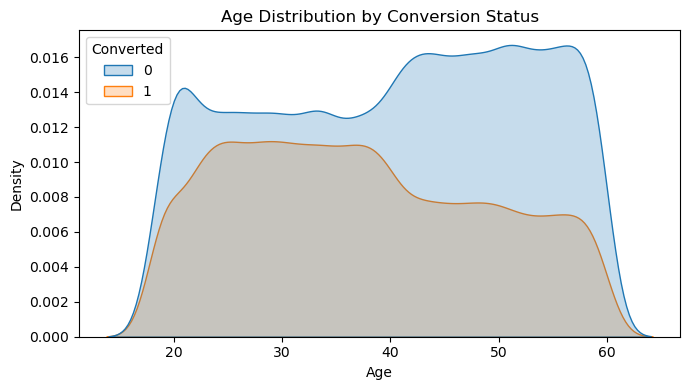

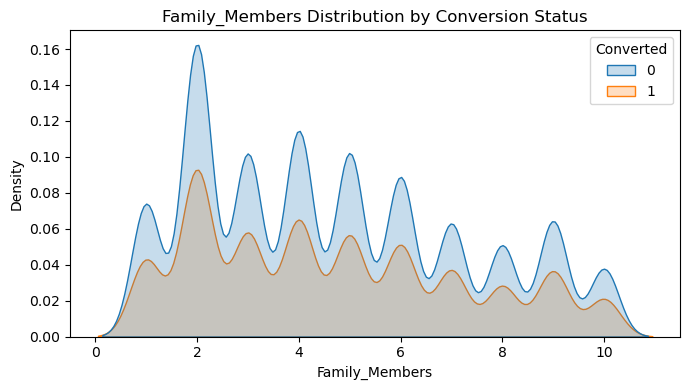

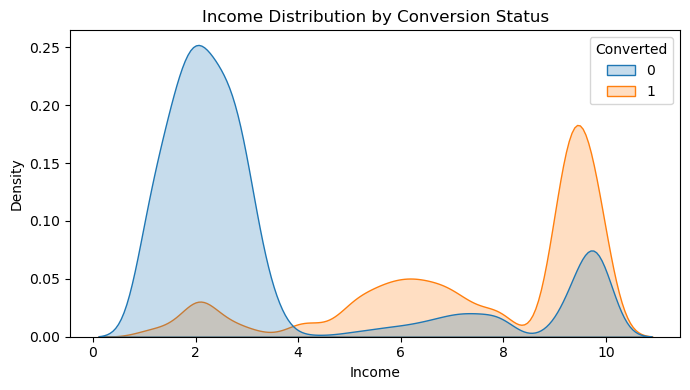

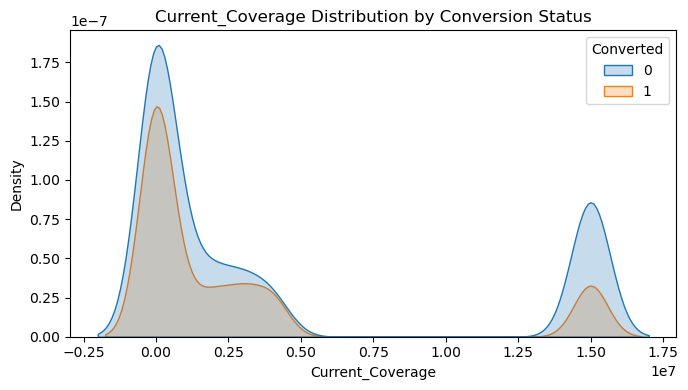

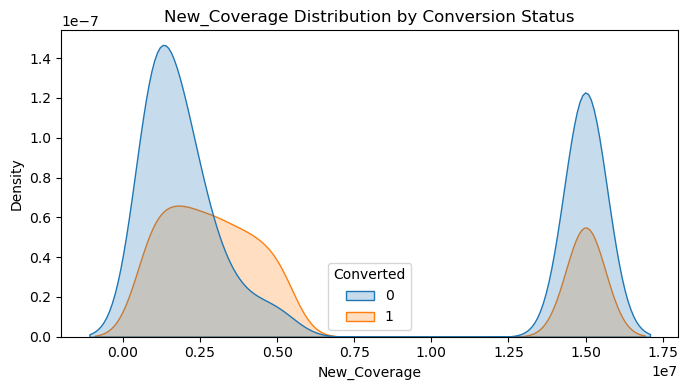

In [251]:
# Numerical column vs Conversion status
num_cols = ['Age','Family_Members','Income','Current_Coverage','New_Coverage']

for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.kdeplot(data=main_data, x=col, hue='Converted', fill=True)
    plt.title(f"{col} Distribution by Conversion Status")
    plt.xlabel(col)   # ✅ fixed spelling (was plt.xlable)
    plt.ylabel('Density')
    plt.tight_layout()
    plt.show()

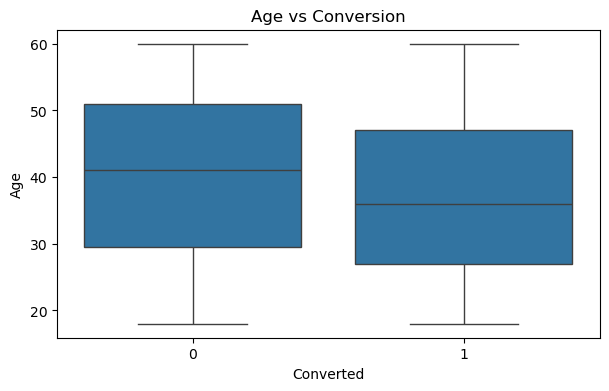

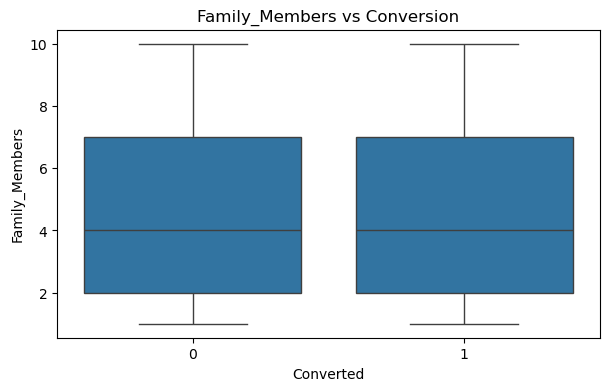

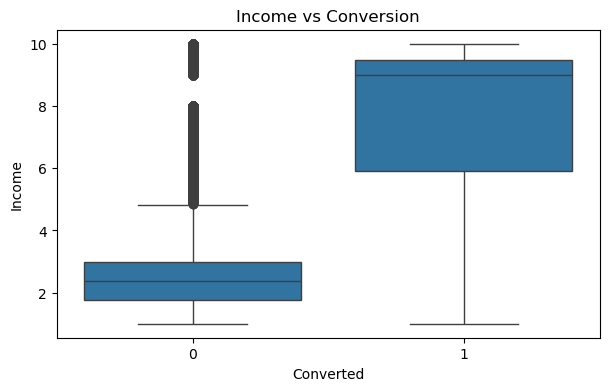

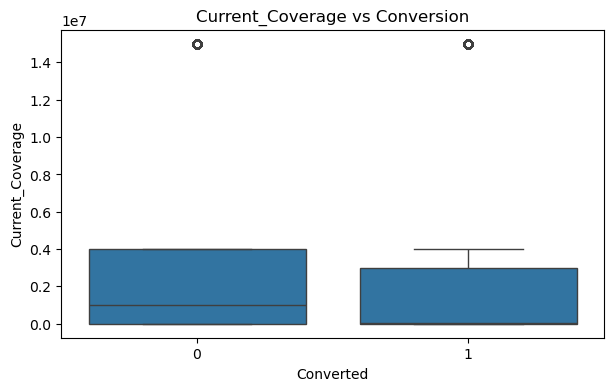

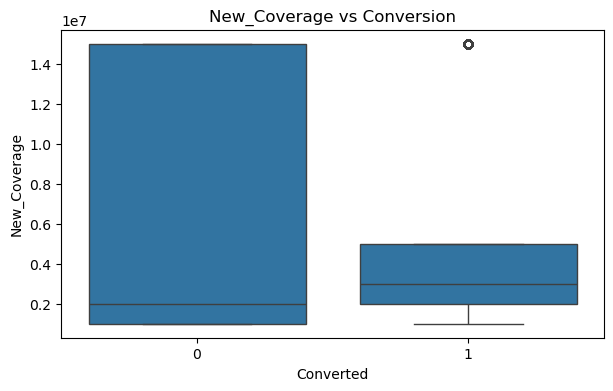

In [252]:
# Let us check the same with Boxplot comparision as well
for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=main_data, x='Converted', y=col)
    plt.title(f'{col} vs Conversion')
    plt.show()

In [253]:
avg = main_data.groupby('Converted')[col].mean().round(2)
print(f"Average {col} by Rating:\n{avg}")

Average New_Coverage by Rating:
Converted
0   6421539.21
1   5597895.34
Name: New_Coverage, dtype: float64


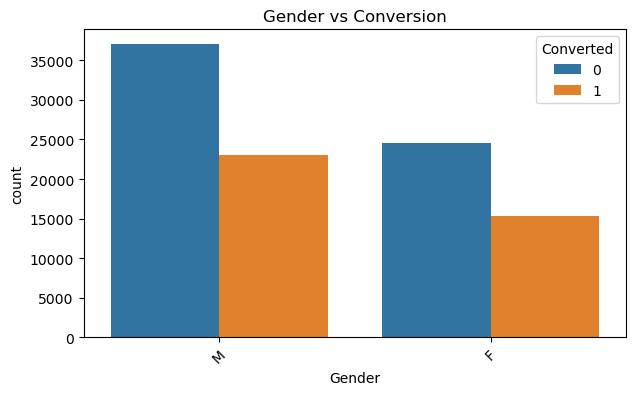

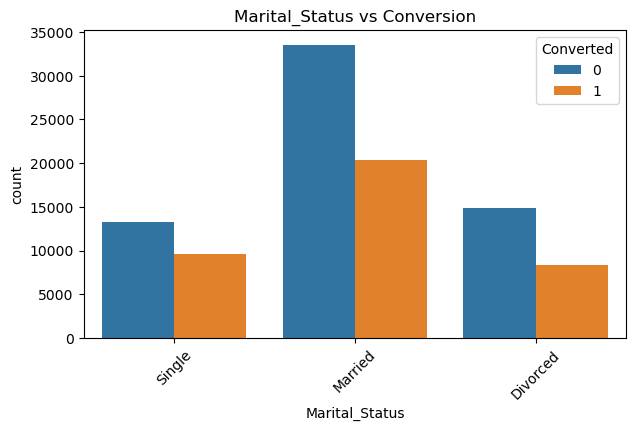

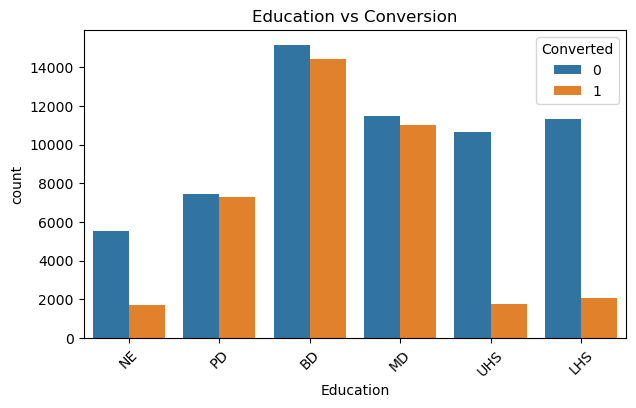

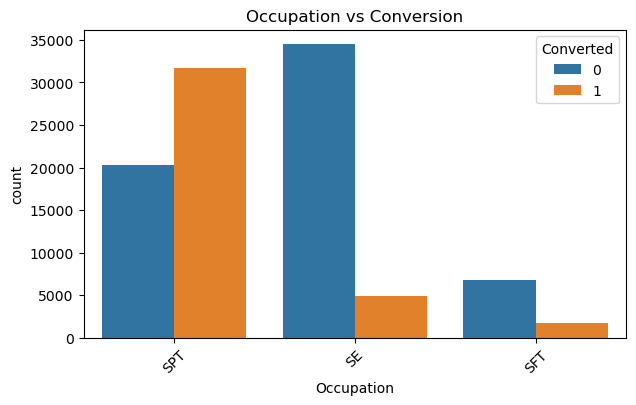

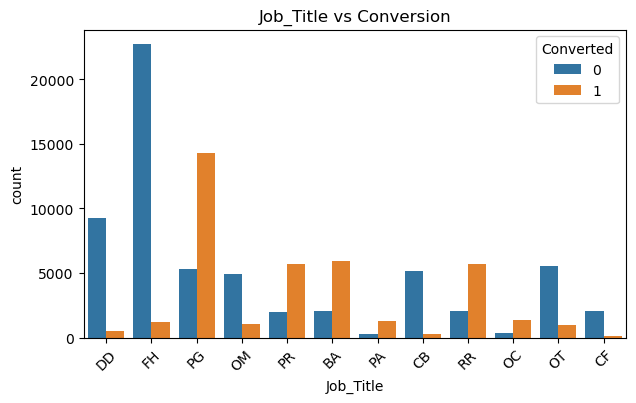

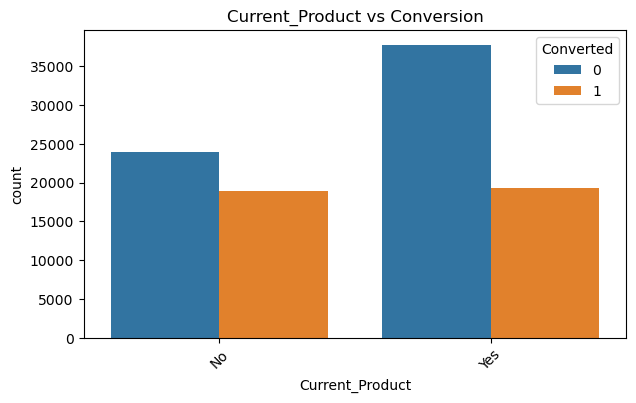

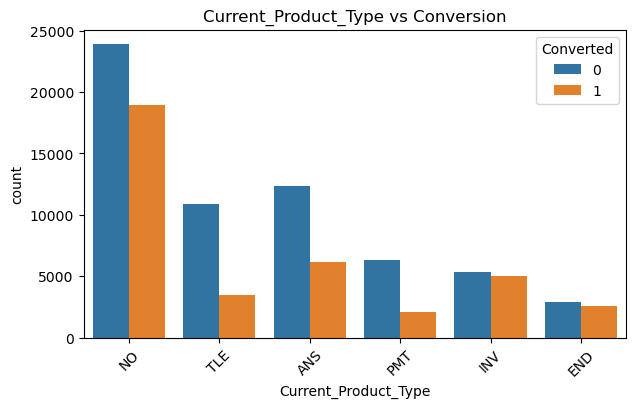

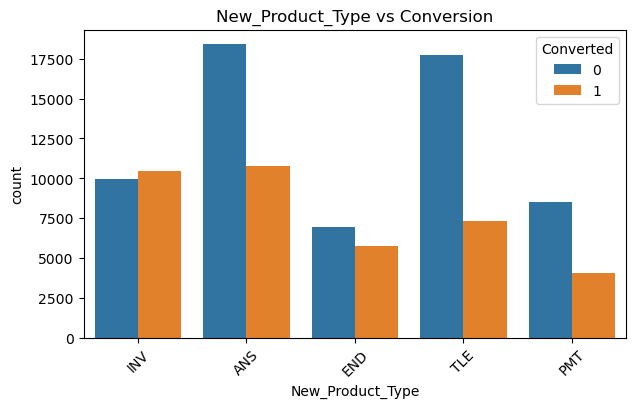

In [254]:
# Now lets us see the same with categorical columns 

cat_cols = ['Gender','Marital_Status','Education','Occupation','Job_Title',
            'Current_Product','Current_Product_Type','New_Product_Type']

for colu in cat_cols:
    plt.figure(figsize=(7,4))
    sns.countplot(data=main_data,x=colu, hue='Converted')
    plt.title(f'{colu} vs Conversion')
    plt.xticks(rotation=45)
    plt.show()

In [255]:
for colu in cat_cols:
    mode_df = (
        main_data.groupby('Converted')[colu].apply(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan).reset_index(name=f'Mode_{colu}')
    )
    print(f"\nMost Frequent {colu} by Converted:")
    print(mode_df)


Most Frequent Gender by Converted:
   Converted Mode_Gender
0          0           M
1          1           M

Most Frequent Marital_Status by Converted:
   Converted Mode_Marital_Status
0          0             Married
1          1             Married

Most Frequent Education by Converted:
   Converted Mode_Education
0          0             BD
1          1             BD

Most Frequent Occupation by Converted:
   Converted Mode_Occupation
0          0              SE
1          1             SPT

Most Frequent Job_Title by Converted:
   Converted Mode_Job_Title
0          0             FH
1          1             PG

Most Frequent Current_Product by Converted:
   Converted Mode_Current_Product
0          0                  Yes
1          1                  Yes

Most Frequent Current_Product_Type by Converted:
   Converted Mode_Current_Product_Type
0          0                        NO
1          1                        NO

Most Frequent New_Product_Type by Converted:
   Converted 

-------------------------------------------------------------------------

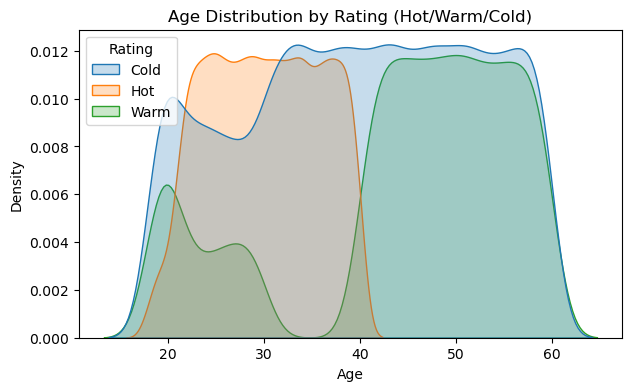

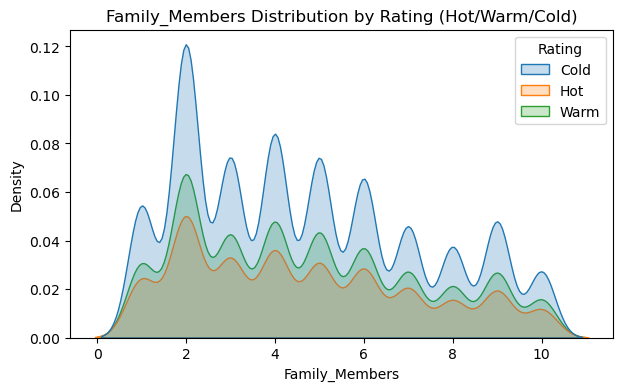

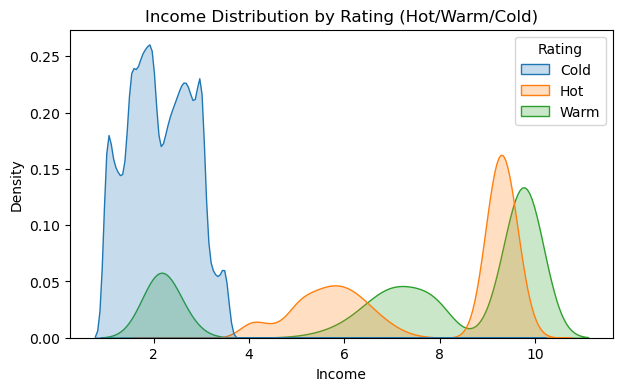

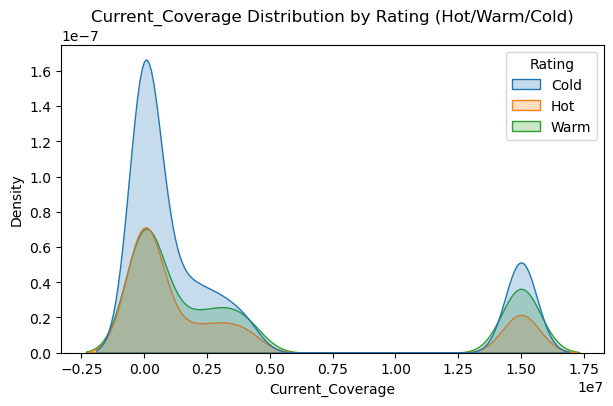

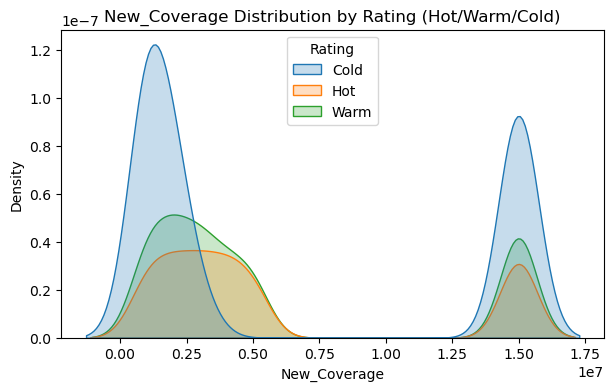

In [257]:
# Now let us do similar analysis by comparing to rating column

# Distribution of Numeric Variables by Rating

num_cols = ['Age','Family_Members','Income','Current_Coverage','New_Coverage']

for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.kdeplot(data=main_data, x=col, hue='Rating', fill=True)
    plt.title(f'{col} Distribution by Rating (Hot/Warm/Cold)')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.show()

In [258]:
avg = main_data.groupby('Rating')[col].mean().round(2)
print(f"Average {col} by Rating:\n{avg}")

Average New_Coverage by Rating:
Rating
Cold   6481650.41
Hot    5804082.88
Warm   5733920.61
Name: New_Coverage, dtype: float64


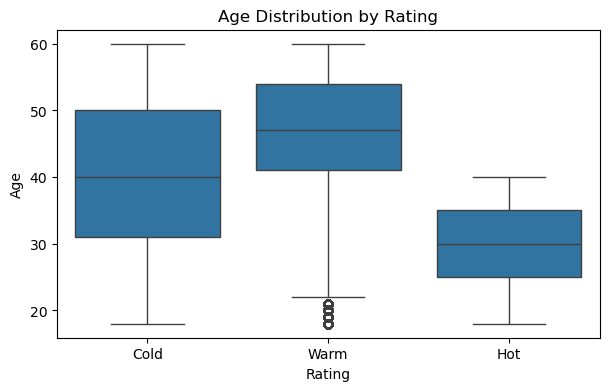

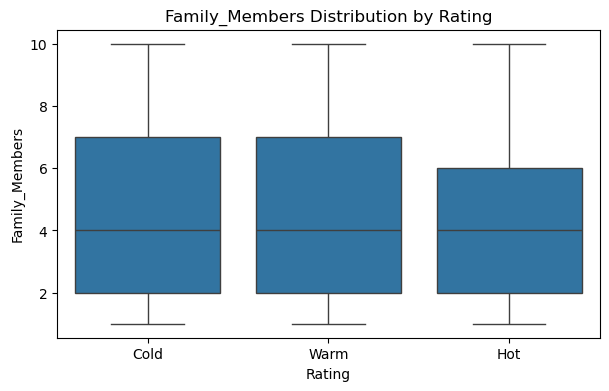

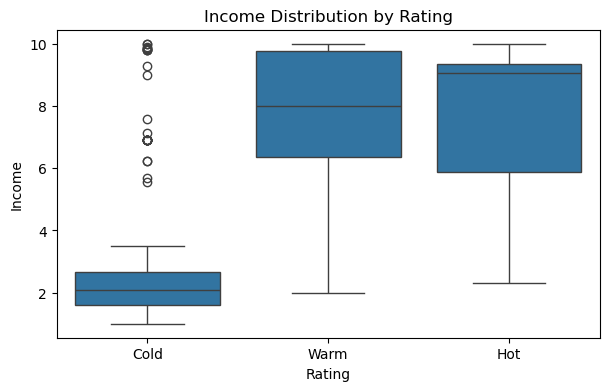

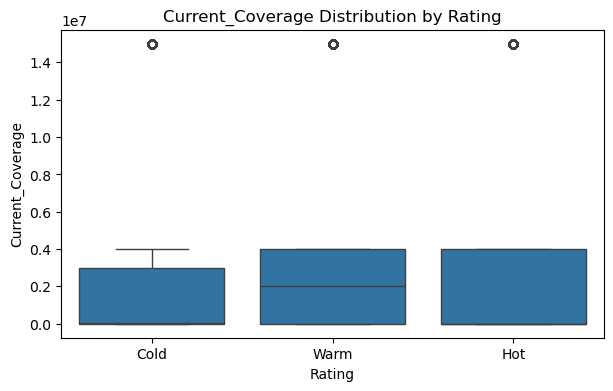

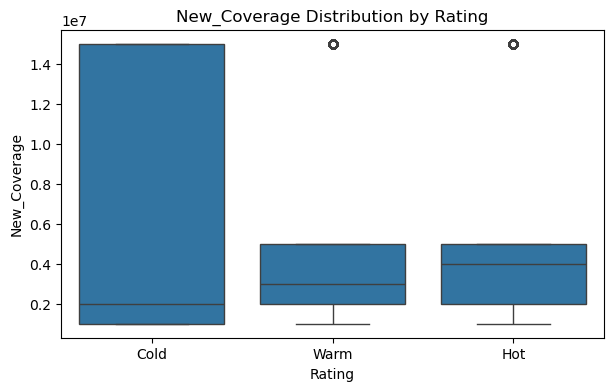

In [259]:
# same we'll do by using boxplot 

for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=main_data, x='Rating', y=col, order=['Cold','Warm','Hot'])
    plt.title(f'{col} Distribution by Rating')
    plt.show()

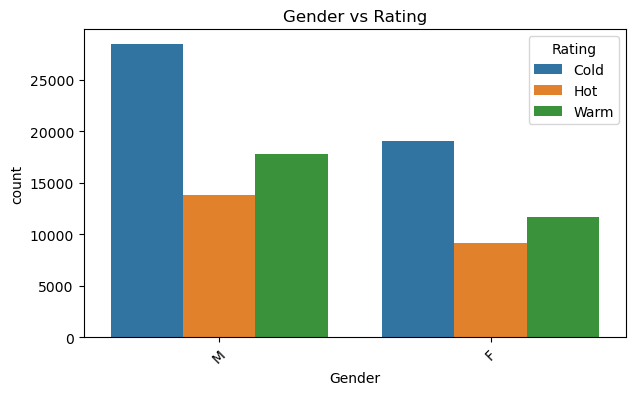

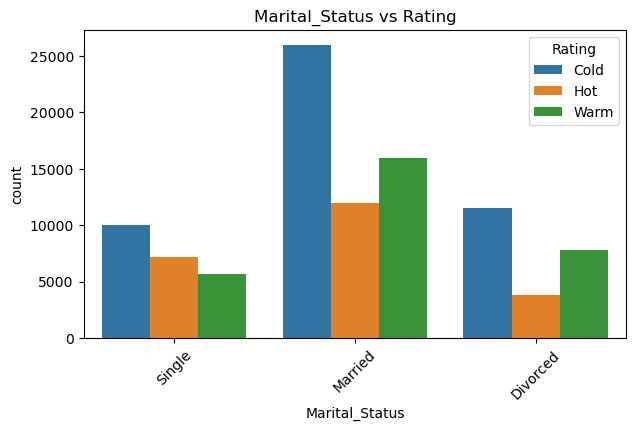

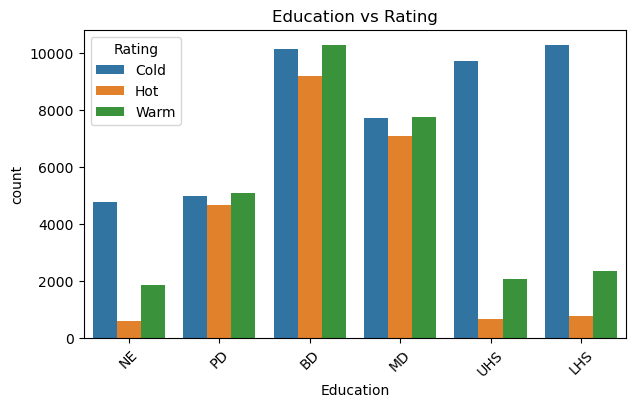

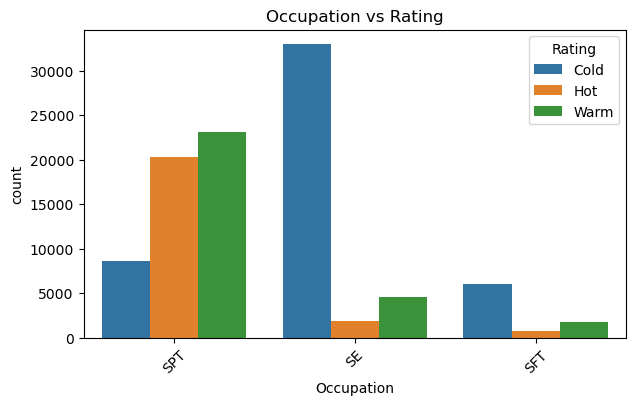

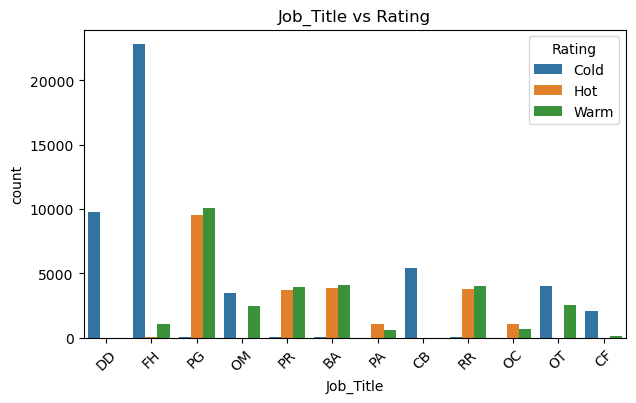

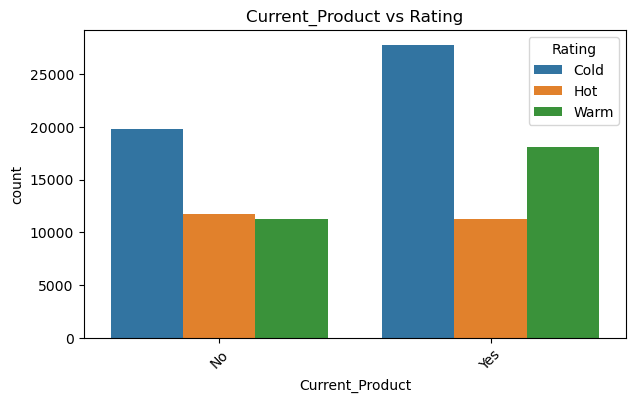

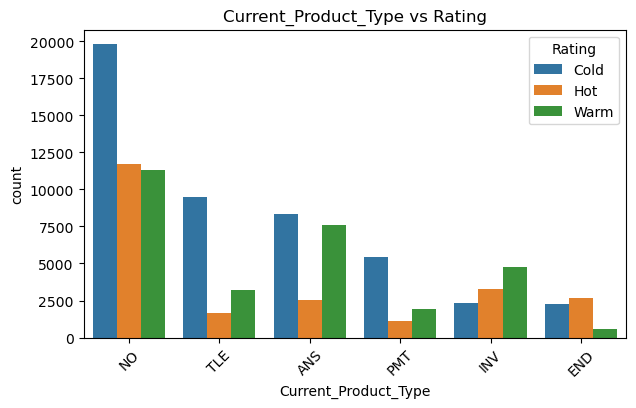

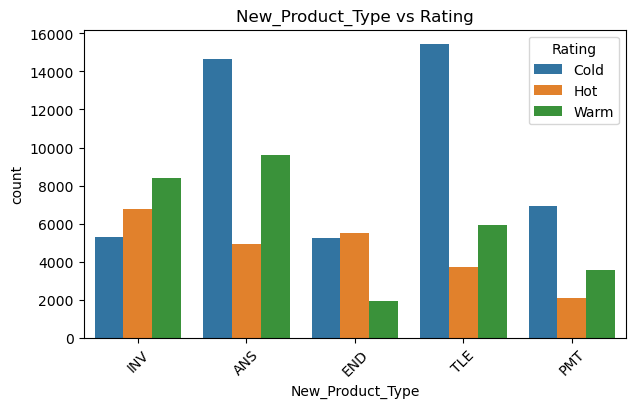

In [260]:
# Now lets check with categorical columns

cat_cols = ['Gender','Marital_Status','Education','Occupation','Job_Title',
             'Current_Product','Current_Product_Type','New_Product_Type']

for col1 in cat_cols:
    plt.figure(figsize=(7,4))
    sns.countplot(data=main_data,x=col1,hue='Rating')
    plt.title(f"{col1} vs Rating")
    plt.xticks(rotation=45)
    plt.show()

In [261]:
for col1 in cat_cols:
    mode_df = (
        main_data.groupby('Rating')[col1].apply(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan).reset_index(name=f'Mode_{col1}')
    )
    print(f"\nMost Frequent {col1} by Rating:")
    print(mode_df)


Most Frequent Gender by Rating:
  Rating Mode_Gender
0   Cold           M
1    Hot           M
2   Warm           M

Most Frequent Marital_Status by Rating:
  Rating Mode_Marital_Status
0   Cold             Married
1    Hot             Married
2   Warm             Married

Most Frequent Education by Rating:
  Rating Mode_Education
0   Cold            LHS
1    Hot             BD
2   Warm             BD

Most Frequent Occupation by Rating:
  Rating Mode_Occupation
0   Cold              SE
1    Hot             SPT
2   Warm             SPT

Most Frequent Job_Title by Rating:
  Rating Mode_Job_Title
0   Cold             FH
1    Hot             PG
2   Warm             PG

Most Frequent Current_Product by Rating:
  Rating Mode_Current_Product
0   Cold                  Yes
1    Hot                   No
2   Warm                  Yes

Most Frequent Current_Product_Type by Rating:
  Rating Mode_Current_Product_Type
0   Cold                        NO
1    Hot                        NO
2   Warm   

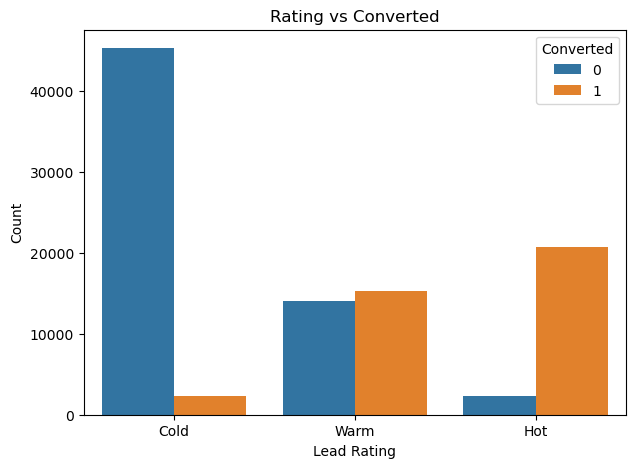

🔹 Conversion Rate (%) within each Rating:
 Converted     0     1
Rating               
Cold      95.13  4.87
Hot       10.13 89.87
Warm      47.85 52.15


In [262]:
# We're now checking Rating vs Converted

plt.figure(figsize=(7,5))
sns.countplot(data=main_data, x='Rating', hue='Converted', order=['Cold','Warm','Hot'])
plt.title('Rating vs Converted')
plt.xlabel('Lead Rating')
plt.ylabel('Count')
plt.show()

# Check conversion % within each rating
conversion_check = pd.crosstab(main_data['Rating'], main_data['Converted'], normalize='index') * 100
print("🔹 Conversion Rate (%) within each Rating:\n", conversion_check.round(2))


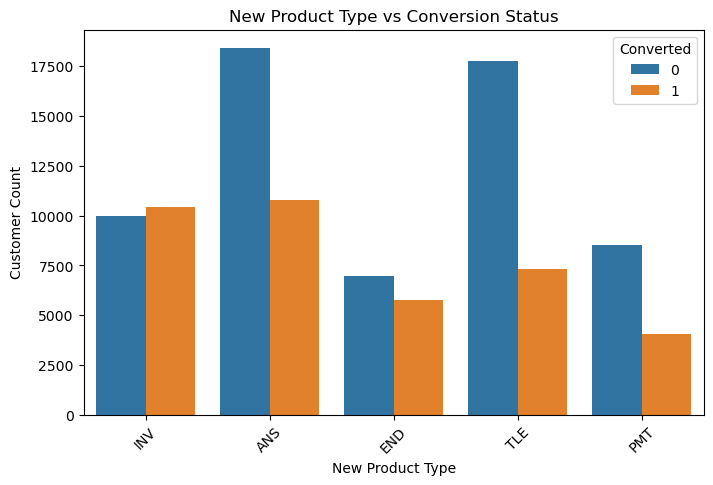

🔹 Conversion Rate (%) by New Product Type:
 Converted            0     1
New_Product_Type            
ANS              63.11 36.89
END              54.80 45.20
INV              48.90 51.10
PMT              67.82 32.18
TLE              70.85 29.15


In [263]:
# To check which product is bought by most customers are 

plt.figure(figsize=(8,5))
sns.countplot(data=main_data, x='New_Product_Type', hue='Converted')
plt.title('New Product Type vs Conversion Status')
plt.xlabel('New Product Type')
plt.ylabel('Customer Count')
plt.xticks(rotation=45)
plt.show()

# Check conversion % by product type
prod_conv = pd.crosstab(main_data['New_Product_Type'], main_data['Converted'], normalize='index') * 100
print("🔹 Conversion Rate (%) by New Product Type:\n", prod_conv.round(2))


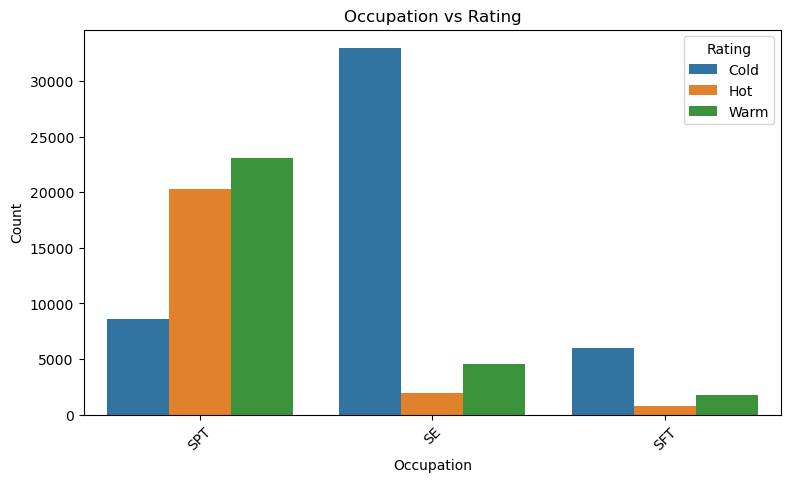

🔹 Rating Distribution (%) within each Occupation:
 Rating      Cold   Hot  Warm
Occupation                  
SE         83.65  4.80 11.55
SFT        70.17  9.20 20.63
SPT        16.57 39.03 44.40


In [264]:
# Now lets check which occupation ppl are most rated 

plt.figure(figsize=(9,5))
sns.countplot(data=main_data, x='Occupation', hue='Rating', order=main_data['Occupation'].value_counts().index)
plt.title('Occupation vs Rating')
plt.xlabel('Occupation')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Rating distribution % by occupation
occ_rating = main_data.groupby('Occupation')['Rating'].value_counts(normalize=True).unstack().fillna(0)*100
print("🔹 Rating Distribution (%) within each Occupation:\n", occ_rating.round(2))

In [265]:

summary = {
    'Rating_vs_Converted': conversion_check.round(2),
    'Product_vs_Converted': prod_conv.round(2),
    'Occupation_vs_Rating': occ_rating.round(2)
}
for name, table in summary.items():
    print(f"\n📊 {name.replace('_',' ')}\n", table)


📊 Rating vs Converted
 Converted     0     1
Rating               
Cold      95.13  4.87
Hot       10.13 89.87
Warm      47.85 52.15

📊 Product vs Converted
 Converted            0     1
New_Product_Type            
ANS              63.11 36.89
END              54.80 45.20
INV              48.90 51.10
PMT              67.82 32.18
TLE              70.85 29.15

📊 Occupation vs Rating
 Rating      Cold   Hot  Warm
Occupation                  
SE         83.65  4.80 11.55
SFT        70.17  9.20 20.63
SPT        16.57 39.03 44.40
